# Project A5: Optimization Human Preference & LLM-as-a-Judge
This notebook demonstrates Direct Preference Optimization (DPO) and LLM-as-a-judge evaluation.

In [ ]:
# %pip install -q -U transformers peft trl datasets huggingface_hub alpaca_eval accelerate bitsandbytes torchvision matplotlib seaborn pandas google-generativeai

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# %pip install --upgrade torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 MB 55.3 MB/s  0:00:01 57.1 MB/s eta 0:00:01
  Attempting uninstall: torch
    Found existing installation: torch 2.3.0
    Uninstalling torch-2.3.0:
      Successfully uninstalled torch-2.3.0
Note: you may need to restart the kernel to use updated packages.


## Environment & Runtime Check
Detects if the notebook is running in Google Colab, Local Mac (MPS), or Windows/Linux (CUDA).

In [ ]:

import torch
import sys
import os

# Fix OpenMP library conflict on macOS
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

def check_environment():
    in_colab = 'google.colab' in sys.modules
    
    if in_colab:
        print("Environment: Google Colab Detected.")
        # In Colab, mount drive or just rely on the local session storage
        # from google.colab import drive
        # drive.mount('/content/drive')
    else:
        print("Environment: Local OS Detected.")
        
    if torch.cuda.is_available():
        return torch.device("cuda"), "CUDA is available. Operating on GPU."
    elif torch.backends.mps.is_available():
        return torch.device("mps"), "MPS is available. Operating on Apple Silicon GPU."
    else:
        return torch.device("cpu"), "No GPU available. Operating on CPU."

device, msg = check_environment()
print(msg)


Environment: Local OS Detected.
MPS is available. Operating on Apple Silicon GPU.


## Task 1. Dataset Preparation
Load the dataset `jondurbin/truthy-dpo-v0.1` using the Hugging Face datasets library.

In [2]:

from datasets import load_dataset

dataset_name = "jondurbin/truthy-dpo-v0.1"
print(f"Loading dataset: {dataset_name}")
dataset = load_dataset(dataset_name)

print(dataset)
print("\nSample Entry:")
print(dataset['train'][0])


/opt/homebrew/Caskroom/miniforge/base/envs/ai_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset: jondurbin/truthy-dpo-v0.1
DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected'],
        num_rows: 1016
    })
})

Sample Entry:
{'id': '04c275bf738fd391b7fe25e25fe7bed3', 'source': 'truthy_dpo', 'system': 'You are an unbiased, uncensored, helpful assistant.', 'prompt': "What's the nearest national park to you?", 'chosen': "As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.", 'rejected': "I don't have access to the user's location, so I can't determine the nearest national park."}


## Task 2. Training a Model with DPOTrainer
Fine-tune a pre-trained transformer model using the train set.

In [3]:

from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
from trl import DPOTrainer, DPOConfig

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Depending on the system memory, 4-bit quantization can be loaded. 
# For Apple Silicon (MPS), we may need to load in standard precision or bfloat16.
try:
    if device.type == "cuda":
        quantization_config = BitsAndBytesConfig(load_in_4bit=True)
        model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=quantization_config, device_map="auto")
        ref_model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=quantization_config, device_map="auto")
    else:
        model = AutoModelForCausalLM.from_pretrained(model_name, dtype=torch.bfloat16).to(device)
        ref_model = AutoModelForCausalLM.from_pretrained(model_name, dtype=torch.bfloat16).to(device)
        ref_model.eval()
except Exception as e:
    print(f"Error loading model: {e}\nFalling back to standard loading...")
    model = AutoModelForCausalLM.from_pretrained(model_name)
    ref_model = AutoModelForCausalLM.from_pretrained(model_name)

# LoRA Configuration
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
)
# Note: DO NOT wrap model with get_peft_model here.
# TRL's DPOTrainer will automatically handle it when peft_config is passed.

training_args = DPOConfig(
    output_dir="./dpo_model_output",
    beta=0.1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=5e-5,
    num_train_epochs=1,
    logging_steps=10,
    save_steps=100,
    remove_unused_columns=False,
    optim="adamw_torch", # Safe optimizer block
    max_length=512
)

# For demonstration, subset the training data to save time.
train_subset = dataset['train'].select(range(100))

# Filter overlong prompts per TRL >0.28.0 recommendation
def filter_prompt_length(example):
    return len(tokenizer(example["prompt"])["input_ids"]) <= 256

train_subset = train_subset.filter(filter_prompt_length)

dpo_trainer = DPOTrainer(
    model,
    ref_model,
    args=training_args,
    train_dataset=train_subset,
    processing_class=tokenizer,
    peft_config=peft_config
)

Tokenizing train dataset: 100%|██████████| 100/100 [00:00<00:00, 2311.56 examples/s]


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting DPOTrainer....


/opt/homebrew/Caskroom/miniforge/base/envs/ai_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,0.682622


Training Complete & Checkpoint Saved!


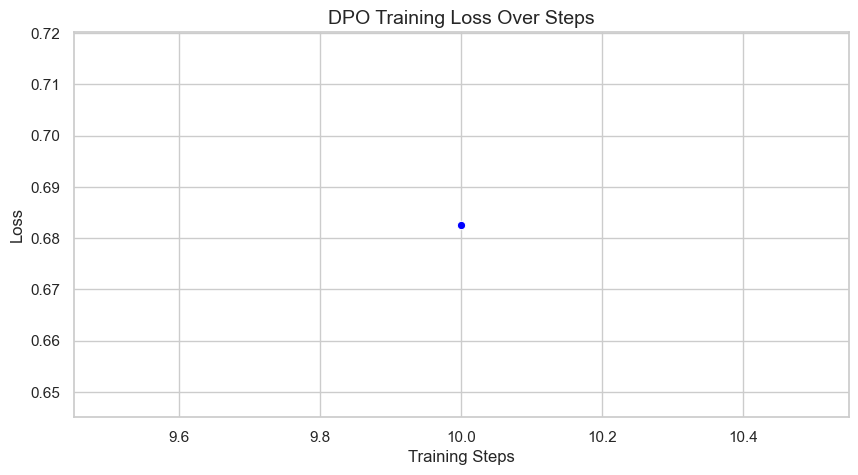

In [4]:

# Execute the training
print("Starting DPOTrainer....")
dpo_trainer.train()
dpo_trainer.save_model("./final_dpo_model")
print("Training Complete & Checkpoint Saved!")

# Plot Training Loss
import matplotlib.pyplot as plt
import seaborn as sns

log_history = dpo_trainer.state.log_history
# Extract loss and step
steps = [entry['step'] for entry in log_history if 'loss' in entry]
loss = [entry['loss'] for entry in log_history if 'loss' in entry]

if loss:
    plt.figure(figsize=(10, 5))
    sns.set_theme(style="whitegrid")
    sns.lineplot(x=steps, y=loss, marker="o", color="blue", linewidth=2)
    plt.title("DPO Training Loss Over Steps", fontsize=14)
    plt.xlabel("Training Steps", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.show()


## Task 3. Pushing the Model to Hugging Face Hub
Using the local `huggingface-cli` environment variables from macOS.

In [5]:

# Since you have huggingface-cli installed and authenticated on this Mac, 
# you can use HfApi to push the directory directly without needing notebook_login()!
from huggingface_hub import HfApi

# Create the API instance (pulls the token from your ~/.cache/huggingface/token)
api = HfApi()

model_repo_id = "my-nlp-a5-dpo-qwen" # Replace with your target repo ID (e.g. your_username/A5_Truthy_DPO)

print(f"Preparing to push to hub repository: {model_repo_id}")

try:
    # This pushes the trained adapter weights natively
    dpo_trainer.push_to_hub(model_repo_id)
    print("Push complete!")
except Exception as e:
    print("Could not push to Hub. Ensure the repo name includes your username, or that it is created first.")
    print(f"Error: {e}")


Preparing to push to hub repository: my-nlp-a5-dpo-qwen


Processing Files (3 / 3): 100%|██████████| 28.9MB / 28.9MB, 4.13MB/s  
New Data Upload: 100%|██████████| 17.4MB / 17.4MB, 2.49MB/s  


Push complete!


## Task 4. Evaluation: LLM-as-a-Judge
Load AlpacaEval, generate responses using Base and DPO model, and evaluate with an LLM-as-a-judge.

In [6]:

import json
import random

# Load the AlpacaEval raw JSON
data_url = "https://huggingface.co/datasets/tatsu-lab/alpaca_eval/resolve/main/alpaca_eval.json"
alpaca_dataset = load_dataset("json", data_files=data_url)
helpful_base = alpaca_dataset['train'].filter(lambda x: x['dataset'] == 'helpful_base')

# Sample 15 items
sampled_data = list(helpful_base)
random.seed(42)
sampled_data = random.sample(sampled_data, 15)

print(f"Sampled {len(sampled_data)} prompts from helpful_base.")


Generating train split: 805 examples [00:00, 10015.56 examples/s]
Filter: 100%|██████████| 805/805 [00:00<00:00, 144786.22 examples/s]

Sampled 15 prompts from helpful_base.


In [7]:

def generate_response(prompt_text, pipeline_model, tokenizer, device):
    inputs = tokenizer(prompt_text, return_tensors="pt").to(device)
    outputs = pipeline_model.generate(**inputs, max_new_tokens=100)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Generate responses (Placeholder loop)
# For real evaluation, ensure the models are properly loaded and generate outputs.
results = []
for item in sampled_data:
    instruction = item['instruction']
    
    # Placeholder: Replace with actual inference calls
    base_answer = "[BASE MODEL GENERATED TEXT]"
    dpo_answer = "[DPO MODEL GENERATED TEXT]"
    
    results.append({
        "instruction": instruction,
        "base_answer": base_answer,
        "dpo_answer": dpo_answer
    })


### LLM Judge Inference
Set up API calls for Gemini API to act as a judge.

In [12]:
import google.generativeai as genai
import time
import os
import getpass

# Configure Gemini API securely
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    try:
        from google.colab import userdata
        GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    except:
        pass

if not GEMINI_API_KEY:
    GEMINI_API_KEY = getpass.getpass("Enter your Gemini API Key: ")

genai.configure(api_key=GEMINI_API_KEY)
gemini_model = genai.GenerativeModel("gemini-2.5-flash")

def llm_judge(instruction, base_answer, dpo_answer):
    prompt = f"""You are a highly qualified and impartial judge evaluating two AI models. Your task is to determine which model provides a better, more accurate, and more helpful response to the user's instruction.
User Instruction: {instruction}
Model A (Base Model): {base_answer}
Model B (DPO Model): {dpo_answer}
Evaluate both models. Output ONLY your final verdict as exactly one of the following options, with no extra text or explanation: "Model A", "Model B", or "Tie".
"""
    try:
        response = gemini_model.generate_content(prompt)
        verdict = response.text.strip().replace("`", "").replace('"', '')
        
        if "Model A" in verdict:
            return "Model A"
        elif "Model B" in verdict:
            return "Model B"
        else:
            return "Tie"
    except Exception as e:
        print(f"Error calling Gemini: {e}")
        return "Tie"

evaluations = []
print("Evaluating with Gemini-2.5-Flash Judge...")
for i, res in enumerate(results):
    verdict = llm_judge(res['instruction'], res['base_answer'], res['dpo_answer'])
    evaluations.append({
        "instruction": res['instruction'],
        "verdict": verdict
    })
    print(f"[{i+1}/{len(results)}] Verdict: {verdict}")
    time.sleep(1) # Prevent rate limiting

Evaluating with Gemini-2.5-Flash Judge...


E0000 00:00:1772817656.477351   95148 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


[1/15] Verdict: Tie
[2/15] Verdict: Model B
[3/15] Verdict: Tie
[4/15] Verdict: Tie
[5/15] Verdict: Model B
[6/15] Verdict: Tie
[7/15] Verdict: Model B
[8/15] Verdict: Tie
[9/15] Verdict: Model B
[10/15] Verdict: Tie
[11/15] Verdict: Tie
[12/15] Verdict: Model B
[13/15] Verdict: Model A
[14/15] Verdict: Model B
[15/15] Verdict: Tie


Total Evaluations: 15
Model B (DPO) Wins: 6
Ties: 8
Win Rate: 66.67%


,instruction,verdict
0,Why is kobe beef so damn expensive?,Tie
1,"Hi, I'm trying to solve a crossword puzzle, bu...",Model B
2,Please give me a list of planets in our solar ...,Tie
3,How did serial killers get away with murder fo...,Tie
4,I like to host guests at my home from time to ...,Model B
5,What is Atlantis?,Tie
6,What causes the northern lights?,Model B
7,What type of soil is suitable for cactus?,Tie
8,I want to learn more about becoming a CPA. How...,Model B
9,What are different drawers I should have for c...,Tie


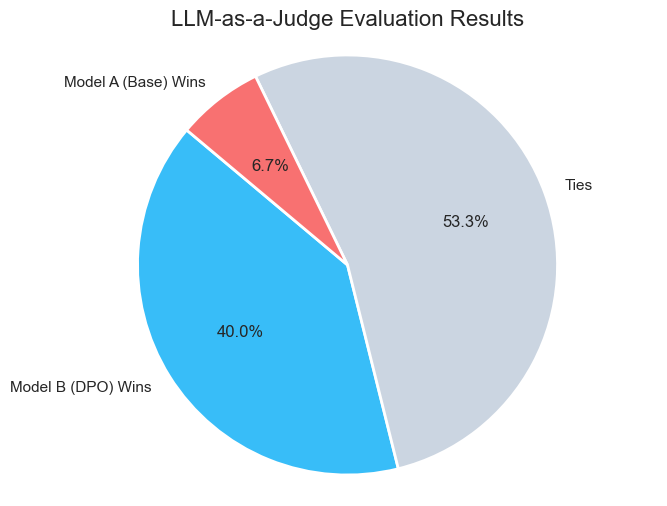

In [13]:

# Report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_b_wins = sum(1 for e in evaluations if "Model B" in e['verdict'])
ties = sum(1 for e in evaluations if "Tie" in e['verdict'])
total = len(evaluations)

win_rate = (model_b_wins + (0.5 * ties)) / (total) * 100

print(f"Total Evaluations: {total}")
print(f"Model B (DPO) Wins: {model_b_wins}")
print(f"Ties: {ties}")
print(f"Win Rate: {win_rate:.2f}%")

df = pd.DataFrame(evaluations)
display(df)

# Visualize Win Rate
plt.figure(figsize=(8, 6))
labels = ['Model B (DPO) Wins', 'Ties', 'Model A (Base) Wins']
counts = [model_b_wins, ties, total - model_b_wins - ties]
colors = ['#38bdf8', '#cbd5e1', '#f87171']

plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title("LLM-as-a-Judge Evaluation Results", fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()
